# REPORT

# 1.0 Abstract
This section contains a high-level overview of the research question, the dataset used, and the key findings and
insights.



# 2.0 Dataset Description

## 2.1 Description of the dataset

The dataset is titled as "Impact of AI on students and it was sourced from Kaggle. It contains various data on the effects of generative AI on students by tracking different attributes such as paid subscription status, weekly AI usage hours, and burnout risk.

## 2.2 How the dataset was collected

We inspected the original source file labeled as "ai_student_impact_dataset (1).csv", but there was no information regarding what specific data collection methodology was used, although it was hinted that stratified sampling was used since the sample count of each major was even across all of them. The dataset had 50,000 observations with zero missing values, which could suggest that it was either synthetically generated or heavily pre-processed. The lack of transparency is quite worrying, but we decided to proceed with the dataset anyway since it is widely used by the Kaggle community, as we saw there were 37 analytical models from different authors.

Additionally, the dataset has a perfect Kaggle Usability score of 10.0 because of its high rating in completeness and compatibility. We assume that the data simulates realistic student metrics and is perhaps a heavily sanitized compilation from various institutions wherein the authors imputed data and perhaps exaggerated the data to reach the 50,000 observations. As stated earlier, the data is popular in the Kaggle community, so there were highly relevant and recent models with the oldest being a month old, and new analyses are being published frequently. This contributes to it having a 100% Kaggle Credibility rating based on source engagement, public notebooks, and update frequency, which increases our confidence that it is credible to be used for our current study.

## 2.3 Potential implications of how the data was collected on the insights that will be generated

* **Self-Reporting and Social Desirability Bias:** 
Some variables, for example Perceived_AI_Dependency, Anxiety_Level_During_Exams, and the weekly hour estimates are self-reported. If a university has a strict rule set, like Institutional_Policy with an outright AI ban, students might report lower AI usage than they actually had, or describe their primary use case in a different way. This can create an artificial separation between AI use and GPA changes in those groups, even when the real relationship is stronger. It can feel like AI is harmless in those datasets but it’s more like the reporting changed.
* **Construct Validity of Metrics:** 
The Skill_Retention_Score works like an objective counterbalance to self-assessments. It aims to measure retained knowledge, so analysts can check whether heavy dependence on AI boosts Post_Semester_GPA while reducing retained understanding over the same period.
* **Cross-Sectional vs. Longitudinal Limitations:** 
Since the tracking runs for one semester only, the takeaways lean toward fast behavioral shifts, not deep, slow habit building. Like, a student with high Weekly_GenAI_Hours might show an immediate GPA uplift, however the way it gradually compounds, on student burnout and long-term academic growth, needs observations over multiple terms. Otherwise it feels sorta limited, because we do not actually see the longer rhythm.

Because the specific origin is unknown and it was hinted that stratified sampling was used for the dataset, there is a high possibility that the insights that will be generated from this study will be generalized. The dataset has no description regarding what specific student population was targeted (such as where it was taken). This results in a decrease in the validity of our results, as different institutions may have different cultures or policies that may externally impact student behavior. Furthermore, if in the case that the dataset is fully synthetic, the findings may reflect the assumptions that were generated by the creation algorithm of the original author, such as, let's say, the author perceived an occasion and exaggerated its population, which may contrast with human trends if there is more sampling.

## 2.4 Structure of the data

Student Academic Profile
* **Student_ID** (INT): Unique identifier
* **Major_Category** (CATEGORICAL): STEM, Business, Humanities, Medical, Arts
* **Years_of_Study** (CATEGORICAL): Freshman, Sophomore, Junior, Senior, Graduate
* **Pre_Semester_GPA** (FLOAT): (1.00 - 4.00)
* **Post_Semester_GPA** (FLOAT): (1.00 - 4.00)
* **Skill_Retention_Score** (FLOAT): (0-100) how well students retain skills post-sem

AI Usage Metrics
* **Weekly_GenAI_Hours** (FLOAT): (0 - 40)
* **Primary_Use_Case** (CATEGORICAL): Copywriting/Drafting, Summarizing_Reading, Debugging/Troubleshooting, Ideation, Direct_Answer_Generation
* **Prompt_Engineering_Skill** (CATEGORICAL): Beginner, Intermediate, Advanced
* **Tool_Diversity** (INT): AI tools used
* **Paid_Subscription** (BOOLEAN): T/F
* **Perceived_AI_Dependency** (INT): Scale 1 (low) to 10 (high)

Other
* **Traditional_Study_Hours** (FLOAT): (1 - 36)
* **Institutional_Policy** (CATEGORICAL): Allowed_With_Citation, Strictly_Ban, Actively_Encouraged

Student Well-Being
* **Anxiety_Level_During_Exams** (INT): Scale 1 (minimal) to 10 (severe)
* **Burnout_Risk_Level** (CATEGORICAL): Low, Medium, High

# 3.0 Data Cleaning & Preprocessing

Although the dataset claimed that it had perfect completeness, balanced distributions, and no pre-processing is required, we decided to do the checks anyway since its unverified methodology is a flag for us to check for quality. We used Python code with pandas so we can check for missing values, duplicate rows, inconsistent categorical encodings, and possible outliers. Lastly, we will do feature engineering to create a new column to find the difference of post and pre-semester GPAs. We also have categorical encoding and feature scaling, which will be applied at another time.

## 3.1 Dataset Loading and Program Initialization


This section is in charge of importing important libraries and reading the dataset for cleaning and processing later.

In [26]:
# USE THE FOLLOWING COMMAND IN NEW CODE BOX: !pip install regex
# Change regex to something like pandas if you dont have that library installed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import difflib
import regex as re
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import scipy.stats as stats
from scipy.stats import chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr

dataset = 'https://raw.githubusercontent.com/HungryDavid/csmodel-dataset/refs/heads/main/ai_student_impact_dataset%20(1).csv'
df = pd.read_csv(dataset)
print(f"Shape: {df.shape}")
print(df.info())
print(df.describe())

Shape: (50000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA      

## 3.2 Data Cleaning

### A. Formatting Categorical Names and Data Types

The first step is to ensure that all the variables were correctly typed and formatted. We checked each of the numerical columns to ensure that no strings were incorrectly mapped, such as finding the string "20" in the weekly Generative AI hours column which is supposed to take a float value. For the categorical columns, we stripped away any accidental whitespaces and standardized the spelling and capitalization by using the difflib library to ensure that the format is consistent across the dataset. The formats for these categories can be found in Section 2.4 (Structure of the Data) of this Jupyter Notebook.

In [27]:
# Check for consistent categorical names
print("Checking For Consistent Categorical Names:\n")
categoricals = []
numericals = []

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col]): # if variable column is float
        numericals.append(col)

    elif pd.api.types.is_bool_dtype(df[col]): # if variable column is boolean
        categoricals.append(col)

    # catches both 'object' and 'string' data types
    elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
        if not df[col].astype(str).str.isdigit().all(): # checks if column is categorical
            categoricals.append(col)

            df[col] = df[col].astype(str).str.strip() # fix whitespace
            raw_counts = df[col].value_counts()

            standard_mapping = {} # standardized the data values
            for unique_val in raw_counts.index:
                lowercase_version = unique_val.lower()
                if lowercase_version not in standard_mapping:
                    standard_mapping[lowercase_version] = unique_val

            # Map values to their most frequent standard casing (e.g. stem to STEM)
            df[col] = df[col].apply(lambda x: standard_mapping[x.lower()])

            legitimate_categories = list(standard_mapping.values())

            def fix_typos(value): # fix spelling (ste to STEM)
                if value in legitimate_categories:
                    return value
                matches = difflib.get_close_matches(value, legitimate_categories, n=1, cutoff=0.5)
                if matches:
                    print(f"Fixed typo from {col}: Changed '{value}' to '{matches[0]}'")
                    return matches[0]
                return value

            df[col] = df[col].apply(fix_typos)

        else: # fix numeric variables ('1' to 1)
            converted_series = pd.to_numeric(df[col], errors='coerce')
            if not converted_series.isnull().all():
                numericals.append(col)
                df[col] = converted_series

max_len = max(len(categoricals), len(numericals))

print(f"{'Index':<6} | {'Categorical Variables':<26} | {'Numerical Variables':<26}")
print("-" * 65)
for i in range(max_len):
    cat_val = categoricals[i] if i < len(categoricals) else ""
    num_val = numericals[i] if i < len(numericals) else ""
    print(f"{i:<6} | {cat_val:<26} | {num_val:<26}")

print("Successfully updated both categorical inconsistencies and numeric type mismatches across all variables\n")

Checking For Consistent Categorical Names:

Index  | Categorical Variables      | Numerical Variables       
-----------------------------------------------------------------
0      | Major_Category             | Student_ID                
1      | Year_of_Study              | Pre_Semester_GPA          
2      | Primary_Use_Case           | Weekly_GenAI_Hours        
3      | Prompt_Engineering_Skill   | Tool_Diversity            
4      | Paid_Subscription          | Traditional_Study_Hours   
5      | Institutional_Policy       | Perceived_AI_Dependency   
6      | Burnout_Risk_Level         | Anxiety_Level_During_Exams
7      |                            | Post_Semester_GPA         
8      |                            | Skill_Retention_Score     
Successfully updated both categorical inconsistencies and numeric type mismatches across all variables



### B. Duplicate Record Check

We checked the dataset for duplicate row entries based on the unique Student_ID, but the result showed that there were no duplicate entries. This was expected anyway, since we know the student IDs simply range from 1 to 50,000 and we were not given actual names.

In [3]:
# Check for duplicate values
print("Checking For Duplicate Values:\n")
duplicate = False
duplicates = df.duplicated(subset=['Student_ID']).sum()
if duplicates != 0:
  print(f"\nNumber of duplicate Student IDs: {duplicates}")
  df = df.drop_duplicates(subset=['Student_ID'])
  print("duplicates have been dropped\n")
  duplicate = True
if duplicate == False:
  print("There are no duplicates. All IDS are unique\n")

Checking For Duplicate Values:

There are no duplicates. All IDS are unique



### C. Missing Values Analysis

We used pandas to scan every column for null or missing values, and just as the Kaggle documentation advertised, the dataset is perfectly complete with no missing values.

In [28]:
# Check for missing values
print("Checkign For Missing Values:\n")
missing = False
for col in df.columns:
  if df[col].isnull().any():
    ids = df[df[col].isnull()]['Student_ID'].tolist()

    print(f"Missing values in col: {col}")
    print(f"Affected Student ID: {ids}")
    missing = True
if missing == False:
  print("There are no missing values\n")

Checkign For Missing Values:

There are no missing values



### D. Handling Outliers

To detect outliers, we used two methods. The first method was establishing logical "hard limits" for human behavior. Since a week has 168 hours, we capped Weekly_GenAI_Hours and Traditional_Study_Hours to a max of 126 hours (even accounting for sleep, I believe this is too high since reaching this requires being on AI 24/7). We also limited Tool_Diversity and Perceived_AI_Dependency to a maximum of 10. For the second method, applied to academic variables, we used the IQR to identify extremes beyond 1.5x the IQR. Ultimately, no outliers were found exceeding these boundaries.

In [5]:
# Check for outliers
# Weekly_GenAI_Hours & Traditional_Study_Hours - assume a person can only use them for 126 hours per week each
# Tool_Diversity -  assume that a person can only use at most 10 tools
# Perceived_AI_Dependency - assume that the rating is within 1-5
# For the others, we use Iqr to determine what is considered an outlier
print("Checking For Outliers:\n")
hard_limits = {
    'Weekly_GenAI_Hours': 126.0,
    'Traditional_Study_Hours': 126.0,
    'Tool_Diversity': 10.0,
    'Perceived_AI_Dependency': 10.0
}

iqr_columns = [
    'Pre_Semester_GPA',
    'Post_Semester_GPA',
    'Anxiety_Level_During_Exams',
    'Skill_Retention_Score'
]

all_checked_variables = list(hard_limits.keys()) + iqr_columns

detailed_outliers_log = []

# header
print(f"{'Variable':<28} | {'Outlier Type':<20} | {'Lower Bound':<11} | {'Upper Bound':<11} | {'Number of Outliers':<18}")
print("-" * 96)

for col in all_checked_variables:
    if col in df.columns:

        if col in hard_limits: # if hard limit
            outlier_type = "Hard Limit"
            low_f = 0.0
            high_f = hard_limits[col]
        else: # if iqr
            outlier_type = "Statistical (IQR)"
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            low_f = Q1 - 1.5 * IQR
            high_f = Q3 + 1.5 * IQR

        outlier_mask = (df[col] < low_f) | (df[col] > high_f)
        outlier_count = outlier_mask.sum() # count outliers per column

        if outlier_count > 0:
            outlier_student_ids = df.loc[outlier_mask, 'Student_ID'].tolist()
            for student_id in outlier_student_ids: # print student id of outlier
                detailed_outliers_log.append(f"Outlier found in {col} (Student ID: {student_id})")

        print(f"{col:<28} | {outlier_type:<20} | {low_f:<11.2f} | {high_f:<11.2f} | {outlier_count:<18}")

print("\n" + "-"*40)
print("Outliers")
print("-"*40)

if detailed_outliers_log:
    for log in detailed_outliers_log[:20]:
        print(log)
    if len(detailed_outliers_log) > 20:
        print(f"... and {len(detailed_outliers_log) - 20} more outlier records found.")
else:
    print("No outliers detected across the dataset variables\n")

print("Data Cleaning of the Dataset has been completed")

Checking For Outliers:

Variable                     | Outlier Type         | Lower Bound | Upper Bound | Number of Outliers
------------------------------------------------------------------------------------------------
Weekly_GenAI_Hours           | Hard Limit           | 0.00        | 126.00      | 0                 
Traditional_Study_Hours      | Hard Limit           | 0.00        | 126.00      | 0                 
Tool_Diversity               | Hard Limit           | 0.00        | 10.00       | 0                 
Perceived_AI_Dependency      | Hard Limit           | 0.00        | 10.00       | 0                 
Pre_Semester_GPA             | Statistical (IQR)    | 1.80        | 4.55        | 328               
Post_Semester_GPA            | Statistical (IQR)    | 1.94        | 4.84        | 346               
Anxiety_Level_During_Exams   | Statistical (IQR)    | -1.50       | 10.50       | 0                 
Skill_Retention_Score        | Statistical (IQR)    | 39.26       | 112

## 3.3 Data Pre-processing

This section focuses on reshaping and transforming variables into clean data for efficient processing. We used three common methods of data pre-processing. Since the second and third methods are for modeling and algorithms we will not be using them just yet.

### A. Feature Engineering

This method focuses on exposing hidden patterns. Since Student_ID can't be used for data modeling , we will drop it. We will also make a new column which is GPA change (positive means better grade and negative means lower grade) to gather new insights and help solve our EDAs and more importantly, our research question.

In [6]:
# drop ID column, not needed for visualization and modeling
processed_df = df.drop(columns=['Student_ID']) 

# Feature Engineering = GPA_change
# check if grade got higher or lower
processed_df['GPA_Change'] = processed_df['Post_Semester_GPA'] - processed_df['Pre_Semester_GPA']

# Print confirmation
print("Feature Engineering Complete: Added 'GPA_Change' column.")
print(f"Current Dataframe Shape: {processed_df.shape}")
print(processed_df[['Pre_Semester_GPA', 'Post_Semester_GPA', 'GPA_Change']].head())

Feature Engineering Complete: Added 'GPA_Change' column.
Current Dataframe Shape: (50000, 16)
   Pre_Semester_GPA  Post_Semester_GPA  GPA_Change
0             2.418              2.393      -0.025
1             3.821              3.696      -0.125
2             3.398              3.499       0.101
3             3.789              4.000       0.211
4             3.635              3.798       0.163


### B. Categorical Encoding

Second is categorical encoding, this essentially turns categorical data into a numerical one through the use of one-hot encoding.

In [ ]:
processed_df = df.drop(columns=['Student_ID']) # remove unnecessary variables
label_enc = LabelEncoder()
columns_to_one_hot = ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']
columns_to_label = ['Year_of_Study', 'Prompt_Engineering_Skill', 'Burnout_Risk_Level']
# one hot encoding
ctoh = False
for col in columns_to_one_hot:
    if col in processed_df.columns:
        processed_df = pd.get_dummies(processed_df, columns=[col], prefix=col, drop_first=True)
        ctoh = True
# encode to labels
ctl = False
for col in columns_to_label:
    if col in processed_df.columns:
        processed_df[col] = label_enc.fit_transform(processed_df[col].astype(str))
        ctl = True
if ctoh and ctl:
  print("Succesfully applied one hot encoding")

### C. Feature Scaling

The final method is feature scaling. Normalization for scaling and for statistical models and algorithms.

In [ ]:
numericals = [
    'Pre_Semester_GPA', 'Post_Semester_GPA', 'Weekly_GenAI_Hours',
    'Traditional_Study_Hours', 'Tool_Diversity', 'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams', 'Skill_Retention_Score', 'Paid_Subscription'
]

# feature scaling using standardization
scaler = StandardScaler()

current_numericals = [col for col in numericals if col in processed_df.columns]

if current_numericals:
    # scale the columns and overwrite them with their standardized versions
    processed_df[current_numericals] = scaler.fit_transform(processed_df[current_numericals])
    print(f"Successfully standardized numeric scales for: {current_numericals}")

# process booleans into 1s and 0s
processed_df = processed_df.astype({col: int for col in processed_df.select_dtypes(include='bool').columns})

print(f"Remaining data types in dataset: {processed_df.dtypes.unique()}")
print(f"Final Dataframe Shape: {processed_df.shape}")
print("Data Pre-preprocessing is complete\nDataset is now prepared for modeling")

# 4.0 Research Question & Exploratory Data Analysis 


The rapid integration of Generative AI in the 2020s sparked our group's interest in its true impact on university students. While AI is widely promoted as a beneficial learning assistant, prevailing discussions often warn that over-reliance may degrade a student's innate creativity and problem-solving skills. To empirically investigate these claims, we acquired a comprehensive dataset from Kaggle to explore the relationship between AI usage patterns and student outcomes.

Initially, we considered highly specific inquiries, such as whether AI functions better as a substitute teacher for explaining concepts, or if it merely serves to alleviate mundane tasks like syntax checking. We hypothesized that utilizing AI with advanced prompt engineering such as treating it with strict parameters to control results might improve a student's academic flexibility and reduce the stress of heavy workloads. Conversely, we questioned if complete reliance on AI would ultimately decrease a student's retained skill level.

By iteratively examining the dataset's available variables, we realized we could track both scholastic trajectories (via our engineered GPA_Change metric) and psychological indicators (such as Anxiety_Level_During_Exams and Burnout_Risk_Level). This allowed us to broaden our scope from specific, isolated behavioral questions into a comprehensive exploration of both academic and mental health impacts. This iterative process led to our finalized general research question:

## 4.1 Main Research Question:

To what extent does a student's reliance on generative AI tools significantly correlate with changes in academic performance and mental well-being?

## 4.2 EDA Questions

To explore our research question and gather evidence, we created four Exploratory Data Analysis questions. The visualizations and statistical summaries generated from these analyses will serve as evidence or supporting information so that we may form a conclusion on whether AI actually has an effect on student academics or well-being.

### A. Does the distribution of academic burnout risk vary significantly across different academic major categories? 

For this analysis, a 100% Stacked Bar Chart is utilized to visualize the proportional distribution of burnout risk levels (Low, Medium, High) across each academic major. As both variables are categorical, we apply the Chi-Square Test of Independence to determine if a student's burnout risk is statistically dependent on their chosen college major.

C:\Users\Matthew Fabregas\AppData\Local\Temp\ipykernel_21524\1375245187.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  contingency_norm = contingency_table.div(contingency_table.sum(1), axis=0)


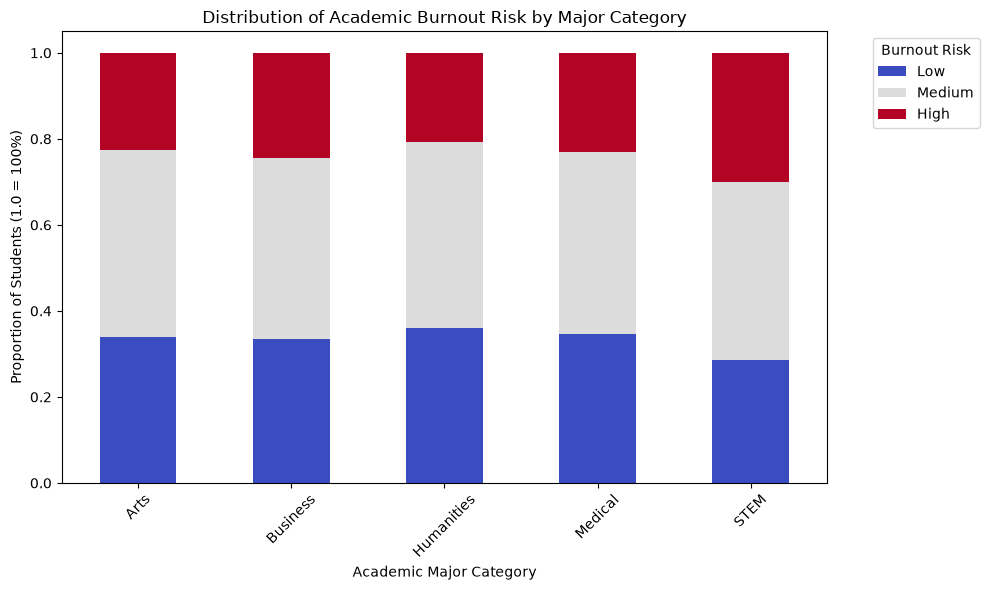

Chi-Square Statistic: 376.2687
P-value: 2.2207e-76

Conclusion: p < 0.05. There is a statistically significant difference in burnout risk across majors.


In [7]:
# cross tab
contingency_table = pd.crosstab(processed_df['Major_Category'], processed_df['Burnout_Risk_Level'])

# Sort
burnout_order = ['Low', 'Medium', 'High']
contingency_table = contingency_table[burnout_order]

# Normalize
contingency_norm = contingency_table.div(contingency_table.sum(1), axis=0)

# Stacked Bar Chart
contingency_norm.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title('Distribution of Academic Burnout Risk by Major Category')
plt.xlabel('Academic Major Category')
plt.ylabel('Proportion of Students (1.0 = 100%)')
plt.legend(title='Burnout Risk', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chi-Square Test of Independence
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

# Print
if p < 0.05:
    print("\nConclusion: p < 0.05. There is a statistically significant difference in burnout risk across majors.")
else:
    print("\nConclusion: p > 0.05. There is NO statistically significant difference.")

Conclusion: The Chi-Square test confirms a statistically significant difference in burnout risk across academic majors (p < 0.05). Furthermore, the 100% Stacked Bar Chart clearly indicates that STEM majors experience a disproportionately high level of severe burnout risk, alongside a much lower rate of low-risk students compared to other fields.

### B. Is there a significant correlation between a student's weekly generative AI hours and their academic performance?

We used a Hexagonal Binning plot to display the density of our data points. We used this instead of a scatter plot because a scatter plot would just look like a filled color due to the sheer amount of observations (overplotting). Additionally, we will use the GPA_Change metric and compare it to Weekly_GenAI_Hours by using the Pearson Correlation Coefficient to test if there is a significant correlation between them.

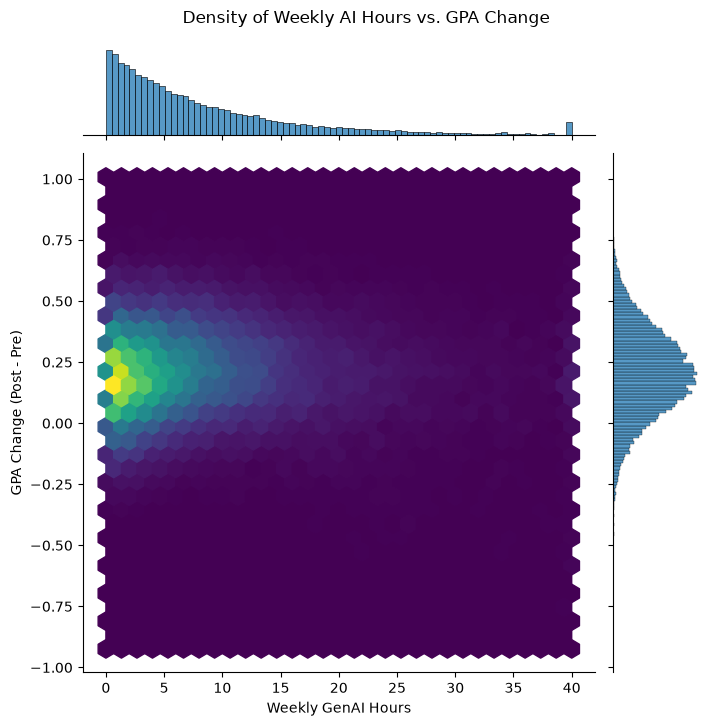

Pearson Correlation Coefficient (r): -0.0465
P-value: 2.5202e-25

Conclusion: p < 0.05. There is a statistically significant correlation.


In [30]:
# Hexagon Binning Plot
hexplot = sns.jointplot(
    data=processed_df,
    x='Weekly_GenAI_Hours',
    y='GPA_Change', 
    kind='hex',
    cmap='viridis',
    gridsize=30,
    height=7
)
hexplot.fig.suptitle('Density of Weekly AI Hours vs. GPA Change', y=1.03)
hexplot.set_axis_labels('Weekly GenAI Hours', 'GPA Change (Post - Pre)')
plt.show()

# Pearson Correlation
corr_coeff, p_value = pearsonr(processed_df['Weekly_GenAI_Hours'], processed_df['GPA_Change'])

print(f"Pearson Correlation Coefficient (r): {corr_coeff:.4f}")
print(f"P-value: {p_value:.4e}")

# Print
if p_value < 0.05:
    print("\nConclusion: p < 0.05. There is a statistically significant correlation.")
else:
    print("\nConclusion: p > 0.05. There is NO statistically significant correlation.")

Graph Observation: The hexbin plot does not have a clear directional trend (like a diagonal line with a lot of dots on it). It shows instead a very dense cluster that is on the left side of the graph. This distribution might look like lower AI usage hours can increase GPA, but because it fails the diagonal test, the correlation fails.

Conclusion: Although the p-value indicates that there is a significant correlation between the two variables, this is simply a product of having a massive sample size, which makes the statistical test overly sensitive. The Pearson correlation coefficient is -0.0465, which indicates a very, very weak negative relationship that can be seen as negligible. Thus, there is practically no correlation and the results are negligible.

### C. Is there a correlation between the institutional policy on AI and the anxiety level of students?

To investigate this question, we first visualize the distribution of exam anxiety scores across the three different institutional policies (Allowed_With_Citation, Strictly_Ban, Actively_Encouraged) using a box plot. We then apply an ANOVA (Analysis of Variance) test to determine if the mean anxiety levels differ significantly between these groups.

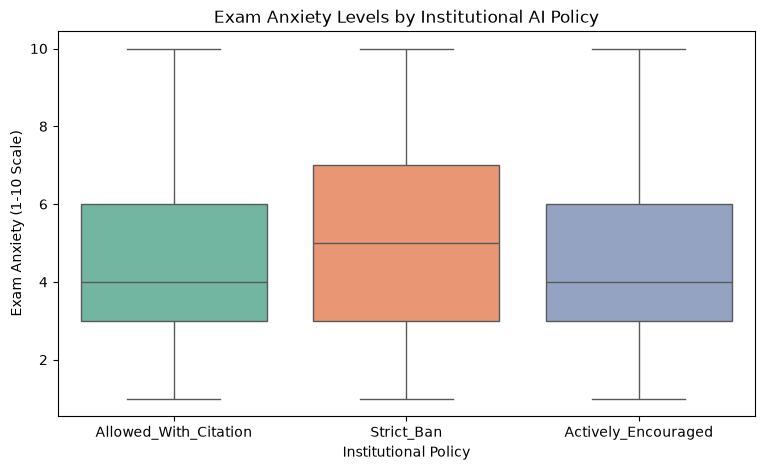

ANOVA F-statistic: 511.7927
P-value: 9.4609e-221

Conclusion: The p-value is < 0.05. There is a statistically significant difference in anxiety levels based on policy.


In [9]:

# BoxPlot
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=processed_df, 
    x='Institutional_Policy', 
    y='Anxiety_Level_During_Exams',
    hue='Institutional_Policy',
    palette='Set2',
    legend=False
)
plt.title('Exam Anxiety Levels by Institutional AI Policy')
plt.xlabel('Institutional Policy')
plt.ylabel('Exam Anxiety (1-10 Scale)')
plt.show()

# ANOVA Test
groups = [group['Anxiety_Level_During_Exams'].values for name, group in processed_df.groupby('Institutional_Policy')]

f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Print
if p_val < 0.05:
    print("\nConclusion: The p-value is < 0.05. There is a statistically significant difference in anxiety levels based on policy.")
else:
    print("\nConclusion: The p-value is > 0.05. There is NO statistically significant difference.")

The ANOVA test indicated that there is a statistically significant difference in anxiety levels across the different institutional policies. To find where the specific differences lie, we used the Tukey post-hoc test. We initially considered the Bonferroni correction as this was discussed in class. However, we think that Tukey's Honest Significant Difference is better for this occasion since it has better comparison logic between different categories.

In [29]:
tukey_results = pairwise_tukeyhsd(
    endog=processed_df['Anxiety_Level_During_Exams'],
    groups=processed_df['Institutional_Policy'],
    alpha=0.05
)

print(tukey_results)

               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------------------
  Actively_Encouraged Allowed_With_Citation   0.0035 0.9863 -0.0478 0.0548  False
  Actively_Encouraged            Strict_Ban   0.7675    0.0  0.7029 0.8322   True
Allowed_With_Citation            Strict_Ban   0.7641    0.0  0.7048 0.8233   True
---------------------------------------------------------------------------------


Conclusion: The ANOVA test confirms a statistically significant difference in anxiety levels among the policy groups (p < 0.05). Furthermore, the Tukey Post-Hoc test reveals that students under a "Strict Ban" will experience a significantly higher anxiety levels compared to those in "Actively Encouraged" or "Allowed with Citation" environments. Conversely, there is no statistically significant difference in anxiety between the "Actively Encouraged" and "Allowed with Citation" policies as they are almost equal.

### D. How does prompt engineering proficiency vary across different years of study? Specifically, do senior students exhibit a higher distribution of advanced prompt engineering skills compared to freshmen? 

For this analysis, a Stacked Bar Chart will be utilized to observe the distribution of prompt engineering skills (Beginner, Intermediate, Advanced) across each academic year. The most appropriate statistical method for this is the Chi-Square Test of Independence as both variables are categorical. The primary goal is to determine if advanced prompt engineering proficiency naturally correlates with higher academic year levels due to increased experience.

C:\Users\Matthew Fabregas\AppData\Local\Temp\ipykernel_21524\305904590.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  contingency_norm = contingency_table.div(contingency_table.sum(1), axis=0)


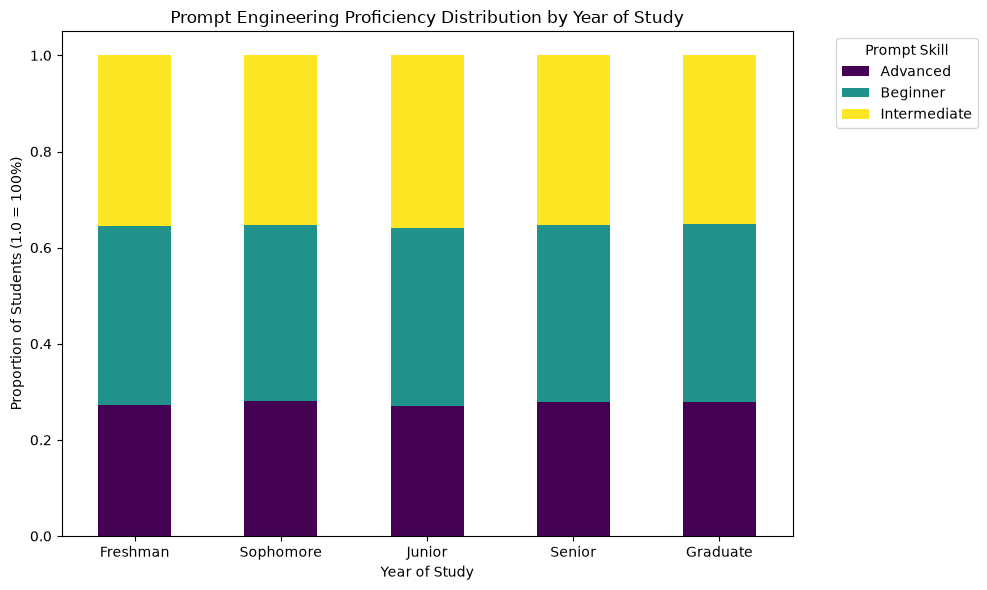

Chi-Square Statistic: 6.2634
P-value: 6.1776e-01

Conclusion: p > 0.05. There is NO statistically significant relationship.


In [11]:
# Cross tab
contingency_table = pd.crosstab(processed_df['Year_of_Study'], processed_df['Prompt_Engineering_Skill'])

# Sort years, freshman to graduate
year_order = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']
contingency_table = contingency_table.reindex(year_order)

# Normalize props
contingency_norm = contingency_table.div(contingency_table.sum(1), axis=0)

# Stacked Bar Chart
contingency_norm.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Prompt Engineering Proficiency Distribution by Year of Study')
plt.xlabel('Year of Study')
plt.ylabel('Proportion of Students (1.0 = 100%)')
plt.legend(title='Prompt Skill', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Chi-Square Test of Independence
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

# Print
if p < 0.05:
    print("\nConclusion: p < 0.05. There is a statistically significant relationship between Year of Study and Prompt Engineering Skill.")
else:
    print("\nConclusion: p > 0.05. There is NO statistically significant relationship.")

Regarding the data integrity: Before reviewing the statistical output, the visual distribution of prompt engineering skills across all academic years appears to be suspiciously uniform. While we noticed a slight variance in the Junior category, it is minuscule and remains highly suspicious overall. This near-perfect distribution serves as a strong empirical red flag, further supporting our initial assumption from Section 2.0 that this dataset is synthetically generated.

Conclusion: Based on the computational evidence, the Chi-Square Test of Independence yields a p-value greater than 0.05, which mathematically confirms our visual intuition. Therefore, we conclude there is no statistically significant relationship between a student's year of study and their prompt engineering proficiency; the proportion of advanced skills remains statistically identical whether a student is a freshman or a graduate.